# FINAL PROJECT - Louie

### LOAN PREDICTION

### 1. Data Cleansing and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn import datasets, linear_model, metrics

In [2]:
df = pd.read_csv("Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
df["Default"].value_counts(normalize=True)

Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64

In [4]:
df.groupby('Default')[['CreditScore','DTIRatio','Income']].median()

,CreditScore,DTIRatio,Income
Default,,,
0,577.0,0.50,84237.5
1,553.0,0.52,66566.0


In [5]:
df[df['Default']==1][['Income','LoanAmount','DTIRatio']].describe()

,Income,LoanAmount,DTIRatio
count,29653.000000,29653.000000,29653.000000
mean,71844.722659,144515.311469,0.512467
std,40785.099507,69547.822943,0.229160
min,15004.000000,5000.000000,0.100000
25%,34022.000000,88085.000000,0.320000
50%,66566.000000,152672.000000,0.520000
75%,106895.000000,205468.000000,0.710000
max,149995.000000,249993.000000,0.900000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [7]:
# Checking for Missing Values
df.isna().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [8]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [9]:
# Checking for Duplicated Values
df.duplicated().sum()

np.int64(0)

In [10]:
# Numerik
num_dtypes = ["int32", "int64", "float32", "float64"]
df_num = df.select_dtypes(include=num_dtypes)
num_cols = df_num.columns.drop("Default")  # buang target

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    fence_low  = q1 - 1.5 * iqr
    fence_high = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < fence_low) | (df[col] > fence_high)]
    print(f"{col} Outlier Count = {len(outliers)}")


Age Outlier Count = 0
Income Outlier Count = 0
LoanAmount Outlier Count = 0
CreditScore Outlier Count = 0
MonthsEmployed Outlier Count = 0
NumCreditLines Outlier Count = 0
InterestRate Outlier Count = 0
LoanTerm Outlier Count = 0
DTIRatio Outlier Count = 0


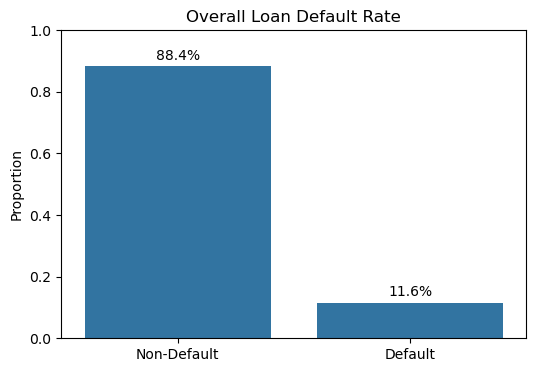

In [12]:
# Hitung proporsi default
default_rate = df["Default"].value_counts(normalize=True).rename(index={0: "Non-Default", 1: "Default"})

plt.figure(figsize=(6,4))
sns.barplot(
    x=default_rate.index,
    y=default_rate.values
)

plt.title("Overall Loan Default Rate")
plt.ylabel("Proportion")
plt.xlabel("")
plt.ylim(0, 1)

# Tambahkan angka di atas bar
for i, v in enumerate(default_rate.values):
    plt.text(i, v + 0.02, f"{v:.1%}", ha='center')

plt.show()

C:\Users\louie\AppData\Local\Temp\ipykernel_2712\2151276157.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Income_Bucket", "Credit_Score_Group"])["Default"]


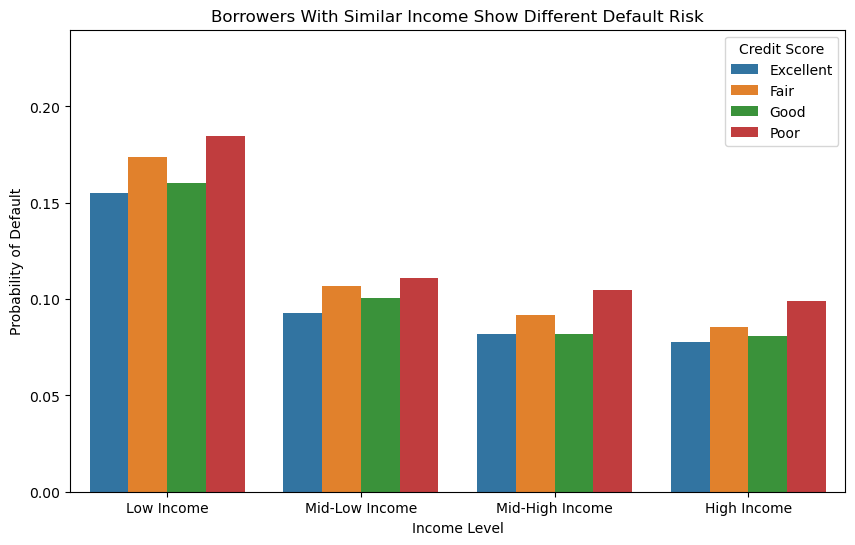

In [17]:
# Bucket income jadi 4 level
df["Income_Bucket"] = pd.qcut(
    df["Income"],
    q=4,
    labels=["Low Income", "Mid-Low Income", "Mid-High Income", "High Income"]
)
def credit_group(score):
    if score < 580:
        return "Poor"
    elif score < 670:
        return "Fair"
    elif score < 740:
        return "Good"
    else:
        return "Excellent"

df["Credit_Score_Group"] = df["CreditScore"].apply(credit_group)
summary = (
    df.groupby(["Income_Bucket", "Credit_Score_Group"])["Default"]
      .mean()
      .reset_index()
)
plt.figure(figsize=(10,6))

sns.barplot(
    data=summary,
    x="Income_Bucket",
    y="Default",
    hue="Credit_Score_Group"
)

plt.title("Borrowers With Similar Income Show Different Default Risk")
plt.ylabel("Probability of Default")
plt.xlabel("Income Level")
plt.ylim(0, summary["Default"].max() * 1.3)
plt.legend(title="Credit Score")

plt.show()

## Feature Engineering

In [45]:
# Binning Credit Score into standard ranges (Poor, Fair, Good, Excellent)
def bin_credit_score(score):
    if score < 580: return 'Poor'
    elif score < 670: return 'Fair'
    elif score < 740: return 'Good'
    else: return 'Excellent'
        
df["Loan_to_Income"] = df["LoanAmount"] / df["Income"]
df["Disposable_Income"] = (df["Income"] / 12) * (1 - df["DTIRatio"])
df["Years_Employed"] = df["MonthsEmployed"] / 12
df["Credit_Score_Group"] = df["CreditScore"].apply(bin_credit_score)
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,...,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Loan_to_Income,Disposable_Income,Years_Employed,Credit_Score_Group
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,...,Divorced,Yes,Yes,Other,Yes,0,0.588262,4013.053333,6.666667,Poor
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,...,Married,No,No,Other,Yes,0,2.467481,1344.853333,1.250000,Poor
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,...,Divorced,Yes,Yes,Auto,No,1,1.534154,4841.960000,2.166667,Poor
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,...,Married,No,No,Business,No,0,1.412638,2034.917500,0.000000,Excellent
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,...,Divorced,No,Yes,Auto,No,0,0.447179,459.832500,0.666667,Fair


In [46]:
df.groupby("Credit_Score_Group")["Default"].mean()

Credit_Score_Group
Excellent    0.101848
Fair         0.114321
Good         0.106289
Poor         0.124748
Name: Default, dtype: float64

## One Hot Encoding

In [47]:
df = df.drop(columns=["LoanID"])
df_object = df.select_dtypes(["object"])
obj_cols = list(df_object.columns)

In [48]:
df_result = pd.get_dummies(df, columns = obj_cols)
df_result

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_No,HasCoSigner_Yes,Credit_Score_Group_Excellent,Credit_Score_Group_Fair,Credit_Score_Group_Good,Credit_Score_Group_Poor
0,56,85994,50587,520,80,4,15.23,36,0.44,0,...,False,False,False,True,False,True,False,False,False,True
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,False,False,False,True,False,True,False,False,False,True
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,False,False,False,False,True,False,False,False,False,True
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,True,False,False,False,True,False,True,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,19,37979,210682,541,109,4,14.11,12,0.85,0,...,False,False,False,True,True,False,False,False,False,True
255343,32,51953,189899,511,14,2,11.55,24,0.21,1,...,False,False,True,False,True,False,False,False,False,True
255344,56,84820,208294,597,70,3,5.29,60,0.50,0,...,False,False,False,False,False,True,False,True,False,False
255345,42,85109,60575,809,40,1,20.90,48,0.44,0,...,False,False,False,True,True,False,True,False,False,False


## Splitting Train Test

In [49]:
X = df_result.drop(columns=["Default"])
y = df_result["Default"]

In [50]:
# stratified random splitting X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify = y)

In [51]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(178742, 38)
(76605, 38)
(178742,)
(76605,)


## Imbalance Problem - Resampling

In [52]:
y_test.value_counts()

Default
0    67709
1     8896
Name: count, dtype: int64

In [53]:
from sklearn.utils import resample
df_train = pd.concat([X_train, y_train], axis=1)

# pisahkan majority dan minority
df_majority = df_train[df_train['Default'] == 0]
df_minority = df_train[df_train['Default'] == 1]

# oversampling: 80% dari jumlah majority (67709)
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=int(0.8 * len(df_majority)),
    random_state=1
)

# gabungkan
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

In [54]:
df_upsampled["Default"].value_counts()

Default
0    157985
1    126388
Name: count, dtype: int64

In [55]:
y_train_up = df_upsampled["Default"]
X_train_up = df_upsampled.drop(columns = ["Default"])

## Hyperparameter Tuning

In [56]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

In [57]:
params = {
    'max_depth': [2,3,5,10],
    'min_samples_leaf': [5,10,20,50,100],
    'n_estimators': [10,25,30,50,100]
}

In [58]:
from sklearn.model_selection import GridSearchCV

# Instantiate the grid search model
grid_search = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 4,
                           n_jobs=-1, verbose=1, scoring="roc_auc")

grid_search.fit(X_train_up, y_train_up)

Fitting 4 folds for each of 100 candidates, totalling 400 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10],
                         'min_samples_leaf': [5, 10, 20, 50, 100],
                         'n_estimators': [10, 25, 30, 50, 100]},
             scoring='roc_auc', verbose=1)

In [59]:
grid_search.best_score_

np.float64(0.8017558106987062)

In [60]:
best_rf_up = grid_search.best_estimator_
best_rf_up

RandomForestClassifier(max_depth=10, min_samples_leaf=5, n_jobs=-1,
                       random_state=42)

In [61]:
best_rf_up.fit(X_train_up, y_train_up)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, n_jobs=-1,
                       random_state=42)

In [62]:
from sklearn.model_selection import GridSearchCV

# Instantiate the grid search model
grid_search_down = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 4,
                           n_jobs=-1, verbose=1, scoring="roc_auc")

grid_search.fit(X_train, y_train)

Fitting 4 folds for each of 100 candidates, totalling 400 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10],
                         'min_samples_leaf': [5, 10, 20, 50, 100],
                         'n_estimators': [10, 25, 30, 50, 100]},
             scoring='roc_auc', verbose=1)

In [63]:
grid_search_down.fit(X_train, y_train)

Fitting 4 folds for each of 100 candidates, totalling 400 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10],
                         'min_samples_leaf': [5, 10, 20, 50, 100],
                         'n_estimators': [10, 25, 30, 50, 100]},
             scoring='roc_auc', verbose=1)

In [64]:
grid_search_down.best_score_

np.float64(0.7437051462097144)

In [65]:
best_rf = grid_search.best_estimator_
best_rf

RandomForestClassifier(max_depth=10, min_samples_leaf=50, n_jobs=-1,
                       random_state=42)

In [66]:
y_rf = best_rf.predict(X_test)
y_rf_up = best_rf_up.predict(X_test)

In [67]:
from sklearn.metrics import accuracy_score
print("Not Resampled:")
print(accuracy_score(y_test, y_rf))

print("Resampled:")
print(accuracy_score(y_test, y_rf_up))

Not Resampled:
0.8850466679720644
Resampled:
0.7866066183669473


In [68]:
from sklearn.metrics import precision_score
print("Not Resampled:")
print(precision_score(y_test, y_rf, pos_label = 1, average='binary'))

print("Resampled:")
print(precision_score(y_test, y_rf_up, pos_label = 1, average='binary'))

Not Resampled:
0.7083333333333334
Resampled:
0.2782308470742306


In [69]:
from sklearn.metrics import recall_score
print("Not Resampled:")
print(recall_score(y_test, y_rf, pos_label = 1, average='binary'))

print("Resampled:")
print(recall_score(y_test, y_rf_up, pos_label = 1, average='binary'))

Not Resampled:
0.017198741007194245
Resampled:
0.5254046762589928


In [70]:
from sklearn.metrics import roc_auc_score
y_rf_prob = best_rf.predict_proba(X_test)[:,1]
y_rf_prob_up = best_rf_up.predict_proba(X_test)[:,1]

print("Not Resampled:")
print(roc_auc_score(y_test, y_rf_prob))

print("Resampled:")
print(roc_auc_score(y_test, y_rf_prob_up))

Not Resampled:
0.7503913010724801
Resampled:
0.7516686061495073


In [71]:
from sklearn.metrics import classification_report
print("Not Resampled:")
print(classification_report(y_test, y_rf))

Not Resampled:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     67709
           1       0.71      0.02      0.03      8896

    accuracy                           0.89     76605
   macro avg       0.80      0.51      0.49     76605
weighted avg       0.86      0.89      0.83     76605



In [73]:
from sklearn.metrics import classification_report
print("Resampled:")
print(classification_report(y_test, y_rf_up))

Resampled:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87     67709
           1       0.28      0.53      0.36      8896

    accuracy                           0.79     76605
   macro avg       0.60      0.67      0.62     76605
weighted avg       0.85      0.79      0.81     76605

